<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo desta aula e LAB explorar os modelos de Redes Neurais Artificiais (ANN - Artificial Neural Network) com Scikit-Learn em Python, sobre os dados da Lego**

Inteligência Artificial - ML com Scikit-learn

PARTE II - LAB

### Dados (LEGO)

LEGO sets released from 1970 to 2022, including details on each set's theme, pieces, recommended age, retail price, and image.

https://mavenanalytics.io/data-playground/lego-sets


## TODO

LAB:

EM DUPLAS (Pairing)<br>
Entrega amanhã (24 horas) em atividade no MS Teams
- Entregar o link do .ipynb no GitHub

- Baixar os dados
- Carregar em data frame Pandas
- Exibir visualmente os dados faltantes
- Organizar e limpar os dados
- Completar os kits de lego (Lego Sets) sem preço
   - Modelagem: Usando redes neurais artificial (ANN)
   - Scikit-learn
- Realizar análise e visualizações
   

Baixando dados do site, com o comando do Linux `wget` e o magic **!**

In [1]:
!wget -nc https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip

--2026-09-29 17:42:33--  https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip
Resolving maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)... 52.217.169.18, 16.182.71.234, 52.216.34.226, ...
Connecting to maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)|52.217.169.18|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 536301 (524K) [application/zip]
Saving to: ‘LEGO+Sets.zip’

LEGO+Sets.zip       100%[===================>] 523.73K  --.-KB/s    in 0.08s   

2026-09-29 17:42:34 (6.41 MB/s) - ‘LEGO+Sets.zip’ saved [536301/536301]



Descompactando arquivo zip

In [2]:
!unzip -o *.zip

Archive:  LEGO+Sets.zip
  inflating: lego_sets.csv           
  inflating: lego_sets_data_dictionary.csv  


Listando os arquivos na pasta atual

In [3]:
!ls -l

total 4380
-rw-r--r-- 1 root root 3936470 Jan  3  2024 lego_sets.csv
-rw-r--r-- 1 root root     532 Jan  3  2024 lego_sets_data_dictionary.csv
-rw-r--r-- 1 root root  536301 Jan  3  2024 LEGO+Sets.zip
drwxr-xr-x 1 root root    4096 Sep 16 13:26 sample_data


Importando LIBs de EDA (Exploratory Data Analisys)


In [4]:
# !pip install missingno  # (descomente se necessário)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


Carregando e visualizando dados

In [5]:
lego_df = pd.read_csv('lego_sets.csv')

lego_df.head()

,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


Buscando os valores faltantes (nulls)

In [6]:
# show missing values
lego_df.isnull().sum()

,0
set_id,0
name,0
year,0
theme,0
subtheme,3556
themeGroup,2
category,0
pieces,3924
minifigs,10058
agerange_min,11670


Visualizando valores faltantes (nulls)

<Axes: >

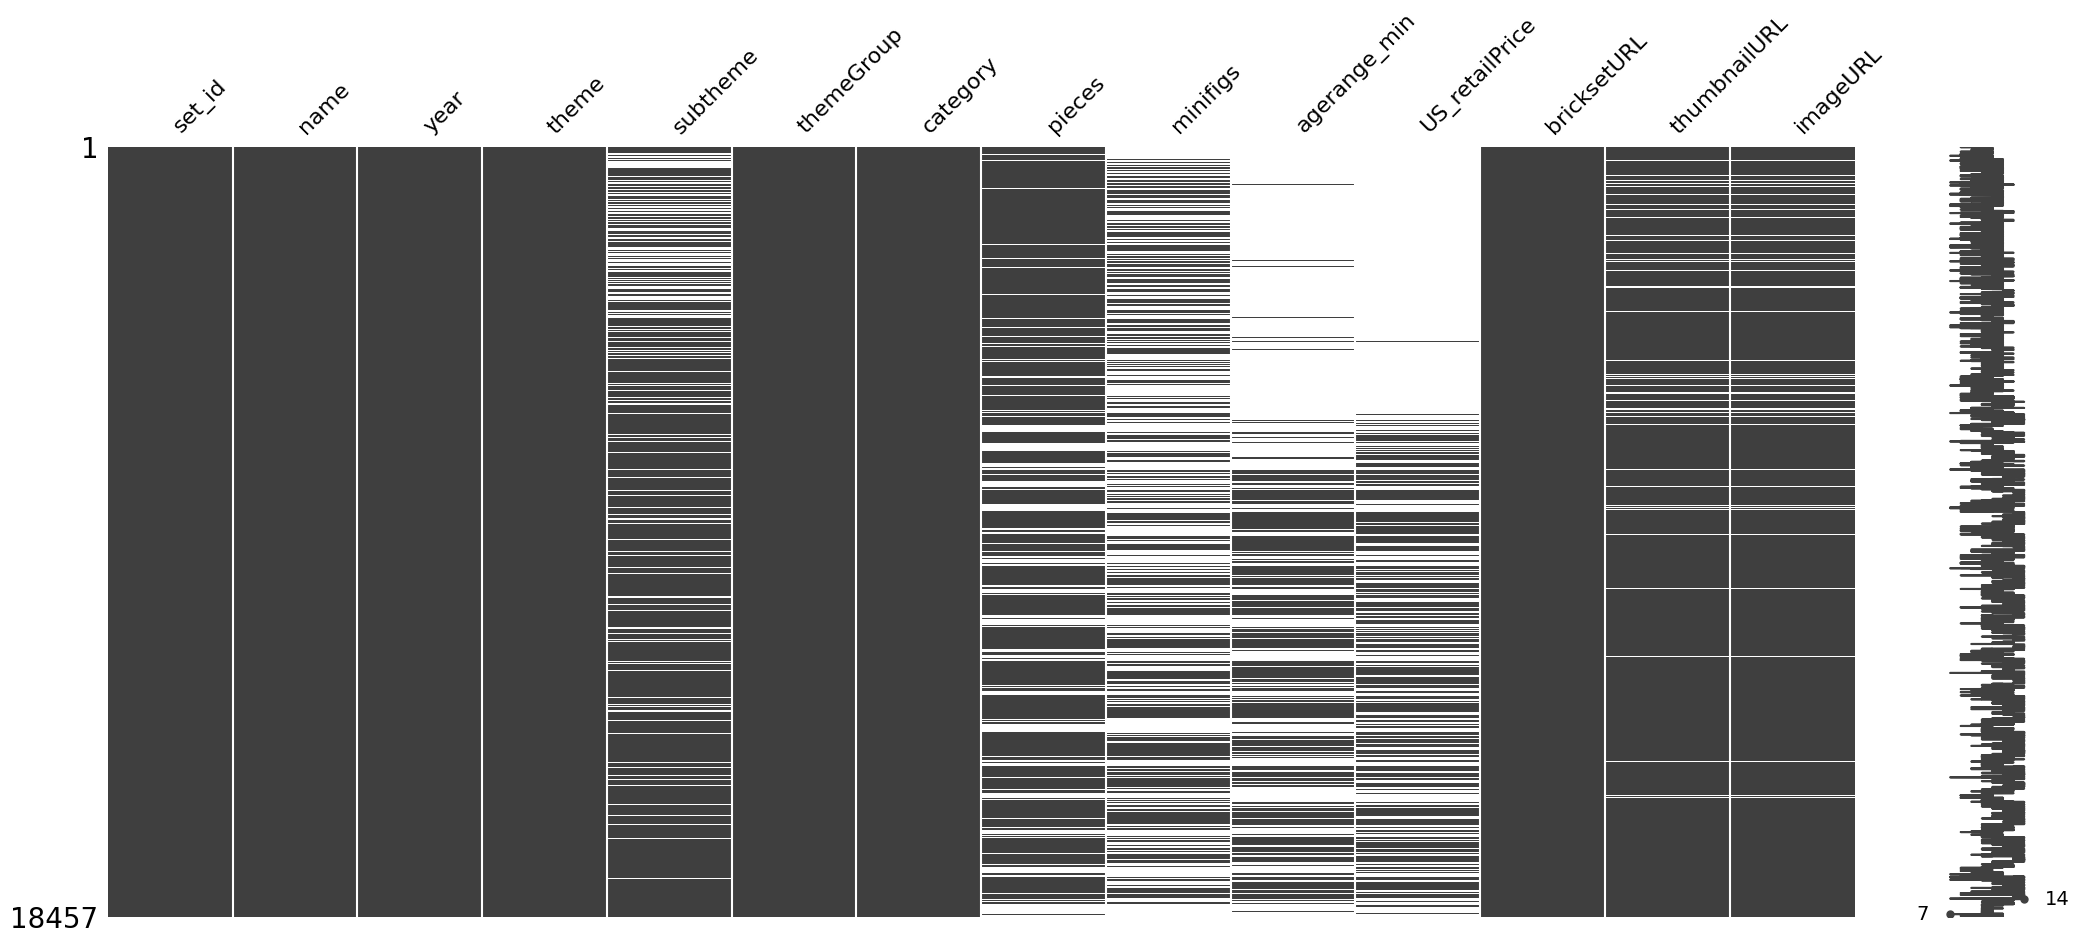

In [7]:
#Visualize missing values
msno.matrix(lego_df)


<Axes: >

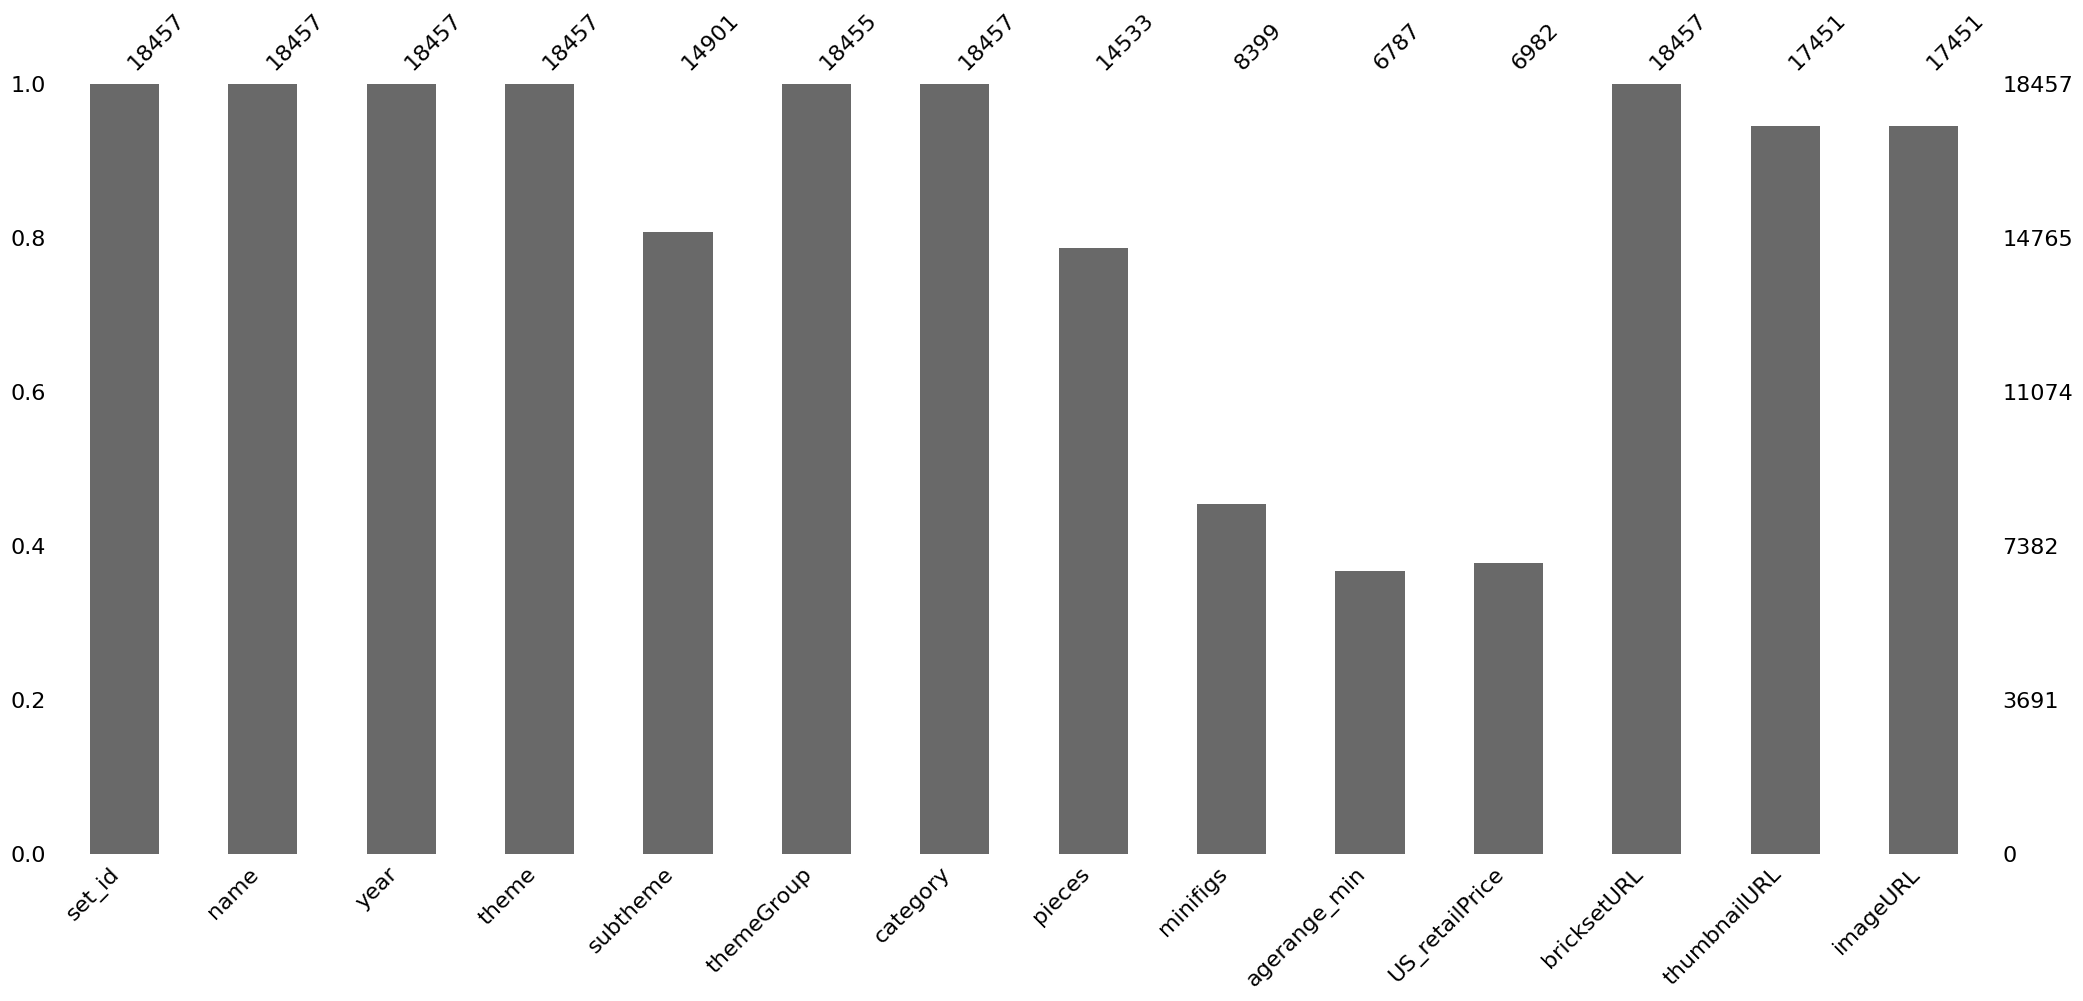

In [8]:
msno.bar(lego_df)


<Axes: >

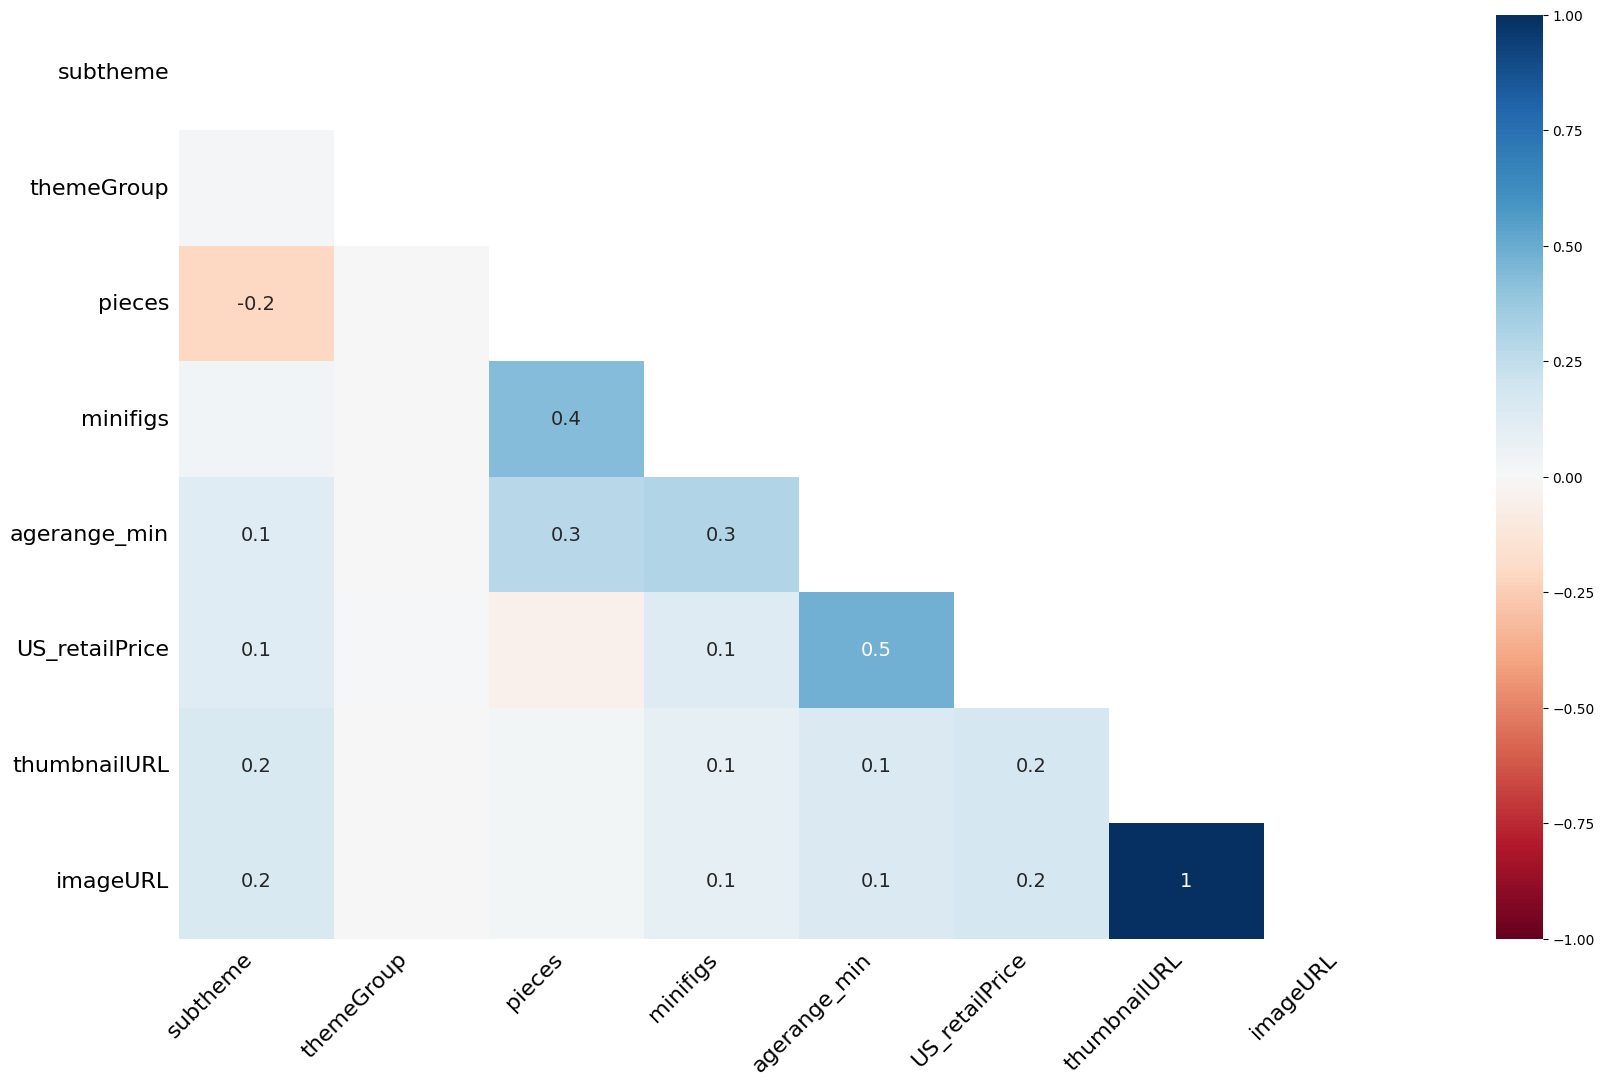

In [9]:
msno.heatmap(lego_df)


Atividade: Criar uma coluna nova `price` e completar usando o modelo de redes neurais do Scikit-Learn (ANN), todos os conjuntos de leve devem ter preço.

Quais as colunas importantes para prever o preço??

---
# Resolução do LAB

**Integrantes (dupla):** Rubens Rodrigues Luiz Sexto de Luiggi Maranesi RA00331129 //
Pedro Gabriel Takenobu Serafim RA00340890

Roteiro:
1. Entendimento dos dados (tipos, estatísticas, faltantes)
2. Organização e limpeza
3. Análise exploratória: **quais colunas importam para prever o preço?**
4. Modelagem com Rede Neural Artificial (`MLPRegressor` do Scikit-Learn)
5. Avaliação e comparação com modelos de referência
6. Criação da coluna `price` completando **todos** os sets
7. Análises e visualizações finais

## 1. Entendimento dos dados

In [10]:
print('Formato:', lego_df.shape)
lego_df.info()

Formato: (18457, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18457 entries, 0 to 18456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   set_id          18457 non-null  object 
 1   name            18457 non-null  object 
 2   year            18457 non-null  int64  
 3   theme           18457 non-null  object 
 4   subtheme        14901 non-null  object 
 5   themeGroup      18455 non-null  object 
 6   category        18457 non-null  object 
 7   pieces          14533 non-null  float64
 8   minifigs        8399 non-null   float64
 9   agerange_min    6787 non-null   float64
 10  US_retailPrice  6982 non-null   float64
 11  bricksetURL     18457 non-null  object 
 12  thumbnailURL    17451 non-null  object 
 13  imageURL        17451 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 2.0+ MB


In [11]:
lego_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
set_id,18457,18457,YOTT-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,18457,15374,Bonus/Value Pack,165,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,18457.0,NaN,NaN,NaN,2007.960611,11.948666,1970.0,2001.0,2011.0,2017.0,2022.0
theme,18457,154,Gear,2832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtheme,14901,895,Magazine Gift,453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
themeGroup,18455,16,Miscellaneous,5891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,18457,7,Normal,12757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pieces,14533.0,NaN,NaN,NaN,226.473749,469.988785,0.0,23.0,70.0,242.0,11695.0
minifigs,8399.0,NaN,NaN,NaN,2.66365,2.897857,1.0,1.0,2.0,3.0,80.0
agerange_min,6787.0,NaN,NaN,NaN,6.637542,2.780091,1.0,5.0,6.0,8.0,18.0


In [12]:
# Percentual de faltantes por coluna
(lego_df.isnull().mean() * 100).sort_values(ascending=False).round(1)

,0
agerange_min,63.2
US_retailPrice,62.2
minifigs,54.5
pieces,21.3
subtheme,19.3
imageURL,5.5
thumbnailURL,5.5
themeGroup,0.0
set_id,0.0
name,0.0


Observações:
- A variável alvo `US_retailPrice` está faltando em cerca de **60%** dos sets — é justamente isso que vamos completar.
- `minifigs` e `agerange_min` também têm muitos faltantes. Em `minifigs`, nulo significa em geral **"sem minifigura"**.
- `pieces` faltante costuma aparecer em itens que não são kits de montagem (livros, chaveiros, roupas, *gear*).
- As colunas de URL não servem para prever preço.

## 2. Organização e limpeza

In [13]:
df = lego_df.copy()

# Remover colunas que não ajudam na modelagem
df = df.drop(columns=['bricksetURL', 'thumbnailURL', 'imageURL'], errors='ignore')

# Remover duplicatas pelo identificador do set
print('Duplicados:', df.duplicated(subset='set_id').sum())
df = df.drop_duplicates(subset='set_id')

# Categóricas: preencher faltantes com um rótulo explícito
df['subtheme'] = df['subtheme'].fillna('Sem subtema')
df['themeGroup'] = df['themeGroup'].fillna('Desconhecido')

# minifigs nulo => 0 minifiguras
df['minifigs'] = df['minifigs'].fillna(0)

# Garantir tipos numéricos
for col in ['year', 'pieces', 'minifigs', 'agerange_min', 'US_retailPrice']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Valores impossíveis: idade mínima > 18 anos é erro de cadastro (ex.: 90) => faltante
print('Idades mínimas inválidas (> 18):', (df['agerange_min'] > 18).sum())
df.loc[df['agerange_min'] > 18, 'agerange_min'] = np.nan

# Indicadores de faltante (a própria ausência carrega informação)
df['pieces_missing'] = df['pieces'].isnull().astype(int)
df['age_missing'] = df['agerange_min'].isnull().astype(int)

# Preços inválidos (<= 0) são tratados como faltantes
df.loc[df['US_retailPrice'] <= 0, 'US_retailPrice'] = np.nan

df.isnull().sum()

Duplicados: 0
Idades mínimas inválidas (> 18): 0


,0
set_id,0
name,0
year,0
theme,0
subtheme,0
themeGroup,0
category,0
pieces,3924
minifigs,0
agerange_min,11670


Os faltantes restantes em `pieces` e `agerange_min` **não** são preenchidos aqui: a imputação (mediana) fica dentro do *pipeline* do modelo, calculada **só no conjunto de treino**, evitando vazamento de dados (*data leakage*).

## 3. Análise exploratória — o que explica o preço?

Sets com preço: 6982  |  sem preço: 11475


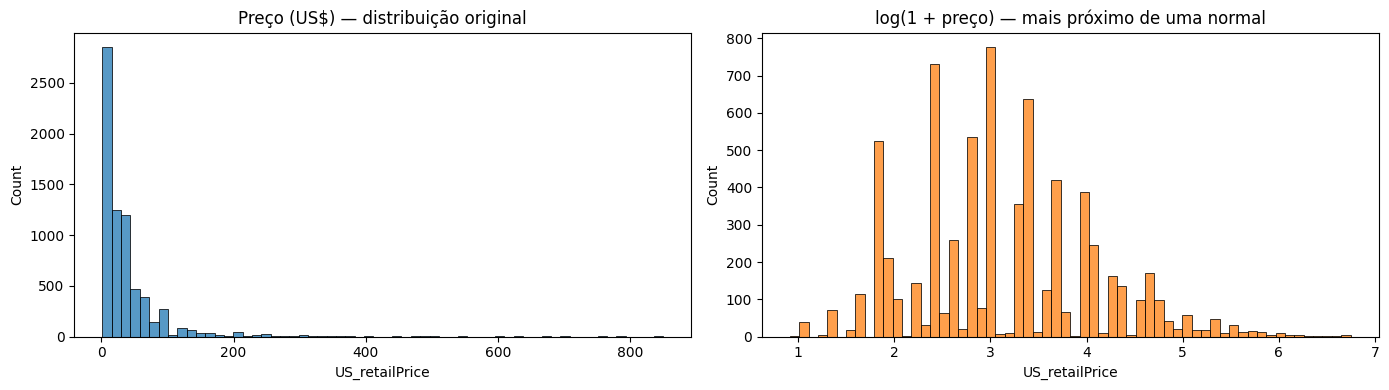

In [14]:
com_preco = df[df['US_retailPrice'].notnull()]
sem_preco = df[df['US_retailPrice'].isnull()]
print(f'Sets com preço: {len(com_preco)}  |  sem preço: {len(sem_preco)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(com_preco['US_retailPrice'], bins=60, ax=axes[0])
axes[0].set_title('Preço (US$) — distribuição original')
sns.histplot(np.log1p(com_preco['US_retailPrice']), bins=60, ax=axes[1], color='tab:orange')
axes[1].set_title('log(1 + preço) — mais próximo de uma normal')
plt.tight_layout(); plt.show()

O preço é muito assimétrico (poucos sets muito caros). Por isso a rede vai prever **log(1+preço)** e depois convertemos de volta.

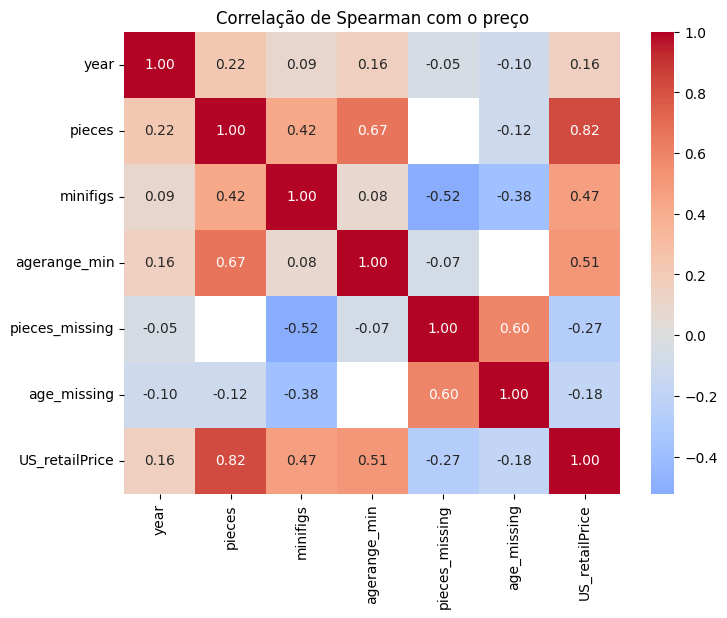

In [15]:
num_cols = ['year', 'pieces', 'minifigs', 'agerange_min', 'pieces_missing', 'age_missing']
corr = com_preco[num_cols + ['US_retailPrice']].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação de Spearman com o preço')
plt.show()

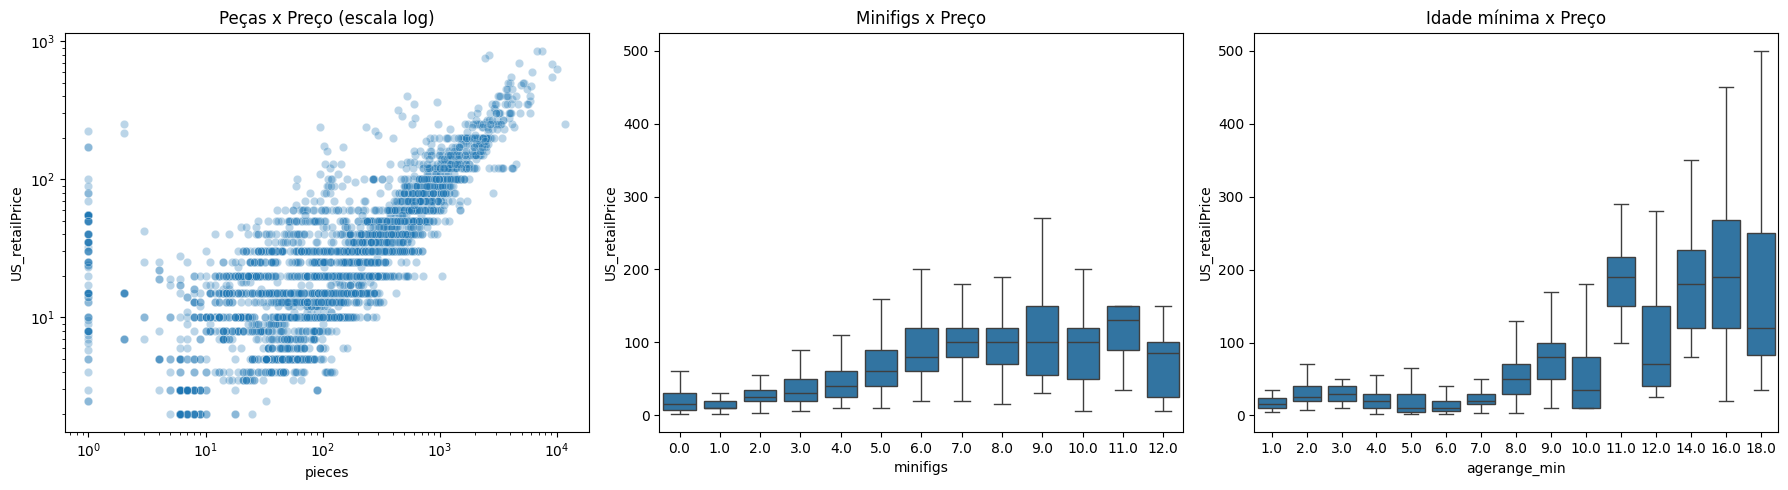

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=com_preco, x='pieces', y='US_retailPrice', alpha=0.3, ax=axes[0])
axes[0].set(xscale='log', yscale='log', title='Peças x Preço (escala log)')
sns.boxplot(data=com_preco, x='minifigs', y='US_retailPrice', ax=axes[1], showfliers=False)
axes[1].set(title='Minifigs x Preço')
axes[1].set_xlim(-0.5, 12.5)
sns.boxplot(data=com_preco, x='agerange_min', y='US_retailPrice', ax=axes[2], showfliers=False)
axes[2].set(title='Idade mínima x Preço')
plt.tight_layout(); plt.show()

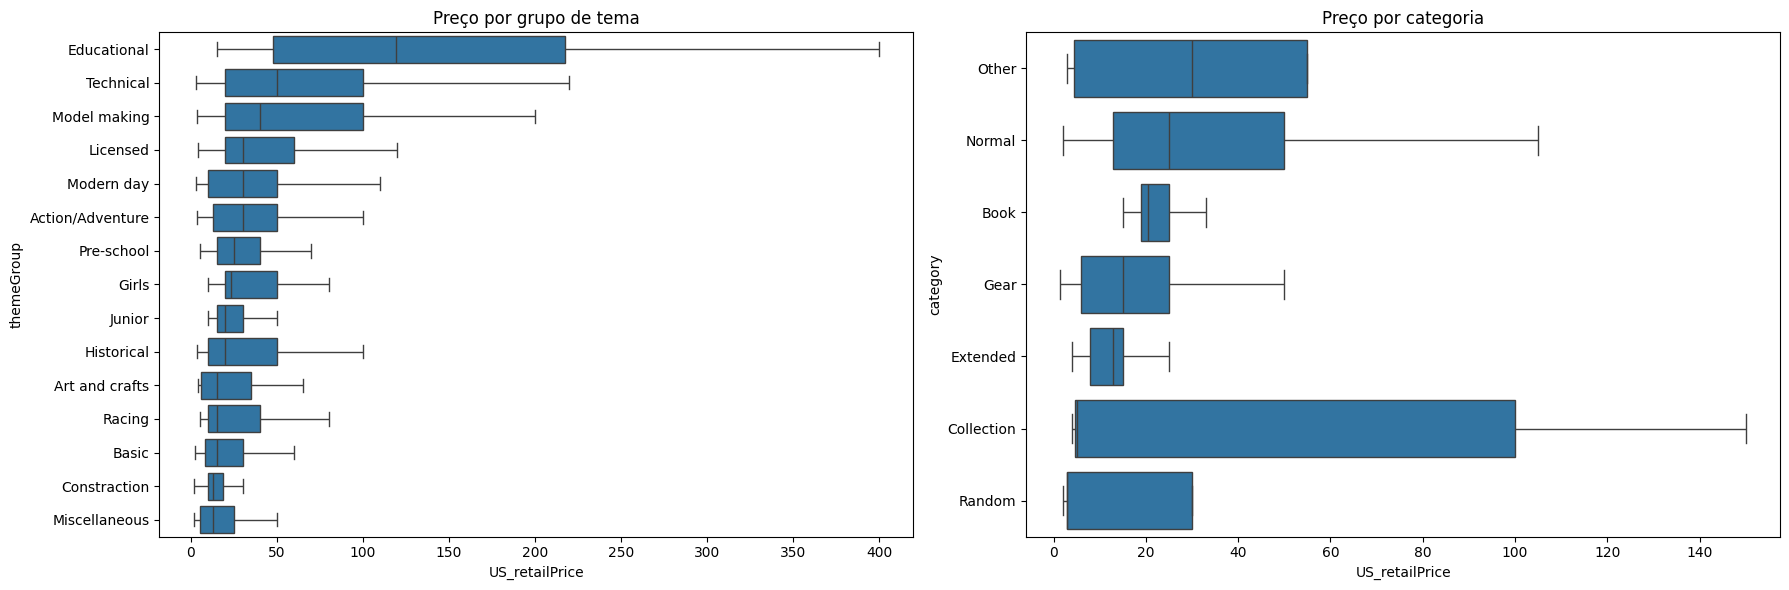

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ordem = com_preco.groupby('themeGroup')['US_retailPrice'].median().sort_values(ascending=False).index
sns.boxplot(data=com_preco, y='themeGroup', x='US_retailPrice', order=ordem, ax=axes[0], showfliers=False)
axes[0].set_title('Preço por grupo de tema')
ordem = com_preco.groupby('category')['US_retailPrice'].median().sort_values(ascending=False).index
sns.boxplot(data=com_preco, y='category', x='US_retailPrice', order=ordem, ax=axes[1], showfliers=False)
axes[1].set_title('Preço por categoria')
plt.tight_layout(); plt.show()

### Quais as colunas importantes para prever o preço?

| Coluna | Usar? | Motivo |
|---|---|---|
| `pieces` | ✅ | Principal preditor — mais peças, mais caro (correlação forte) |
| `minifigs` | ✅ | Minifiguras agregam valor ao set |
| `agerange_min` | ✅ | Sets para idades maiores são mais complexos/caros |
| `year` | ✅ | Inflação e mudanças de política de preços ao longo do tempo |
| `theme` / `themeGroup` | ✅ | Temas licenciados (Star Wars, Harry Potter…) e linhas premium custam mais |
| `category` | ✅ | Diferencia kit normal, *gear*, livros, colecionáveis etc. |
| `subtheme` | ⚠️ | Muitas categorias raras; usamos só as mais frequentes (`min_frequency`) |
| `set_id`, `name`, URLs | ❌ | Identificadores/texto livre, sem relação direta com preço |

## 4. Modelagem com Rede Neural Artificial (MLP)

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

features_num = ['year', 'pieces', 'minifigs', 'agerange_min', 'pieces_missing', 'age_missing']
features_cat = ['theme', 'themeGroup', 'category', 'subtheme']
features = features_num + features_cat
target = 'US_retailPrice'

X = com_preco[features]
y = com_preco[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Treino:', X_train.shape, ' Teste:', X_test.shape)

Treino: (5585, 10)  Teste: (1397, 10)


**Pré-processamento** (tudo dentro de um `Pipeline`):
- Numéricas: imputação pela mediana → `log1p` (para `pieces`/`minifigs`, reduz assimetria) → padronização (`StandardScaler`). Redes neurais são sensíveis à escala!
- Categóricas: *One-Hot Encoding*, agrupando categorias raras (`min_frequency`) e ignorando categorias novas.
- Alvo: `TransformedTargetRegressor` treina em `log1p(preço)` e devolve em dólares com `expm1`.

In [19]:
log_cols = ['pieces', 'minifigs']
outras_num = [c for c in features_num if c not in log_cols]

preprocess = ColumnTransformer([
    ('log_num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p)),
        ('sc', StandardScaler())]), log_cols),
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc', StandardScaler())]), outras_num),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10,
                          sparse_output=False), features_cat),
])

def make_model(regressor):
    return TransformedTargetRegressor(
        regressor=Pipeline([('prep', preprocess), ('reg', regressor)]),
        func=np.log1p, inverse_func=np.expm1)

mlp = MLPRegressor(hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
                   alpha=1e-3, learning_rate_init=1e-3, max_iter=500,
                   early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
                   random_state=42)
ann_model = make_model(mlp)

### Busca de hiperparâmetros (GridSearchCV, validação cruzada 3-fold)

In [20]:
param_grid = {
    'regressor__reg__hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)],
    'regressor__reg__alpha': [1e-4, 1e-3, 1e-2],
}
grid = GridSearchCV(ann_model, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train, y_train)

print('Melhores hiperparâmetros:', grid.best_params_)
print(f'MAE médio na validação cruzada: US$ {-grid.best_score_:.2f}')
best_ann = grid.best_estimator_

Melhores hiperparâmetros: {'regressor__reg__alpha': 0.001, 'regressor__reg__hidden_layer_sizes': (64,)}
MAE médio na validação cruzada: US$ 8.39


In [21]:
pd.DataFrame(grid.cv_results_)[['param_regressor__reg__hidden_layer_sizes', 'param_regressor__reg__alpha',
                               'mean_test_score', 'std_test_score']] \
  .assign(MAE=lambda d: -d['mean_test_score']).sort_values('MAE').drop(columns='mean_test_score')

,param_regressor__reg__hidden_layer_sizes,param_regressor__reg__alpha,std_test_score,MAE
3,"(64,)",0.0010,0.473999,8.387186
0,"(64,)",0.0001,0.457711,8.422939
6,"(64,)",0.0100,0.445438,8.444658
7,"(128, 64)",0.0100,0.714171,8.574275
4,"(128, 64)",0.0010,0.779239,8.676168
1,"(128, 64)",0.0001,0.794644,8.738614
2,"(256, 128, 64)",0.0001,0.424019,8.771913
8,"(256, 128, 64)",0.0100,0.490160,8.790490
5,"(256, 128, 64)",0.0010,0.465816,8.833002


## 5. Avaliação no conjunto de teste e comparação

In [22]:
def avaliar(nome, modelo):
    pred = modelo.predict(X_test)
    return {'Modelo': nome,
            'MAE (US$)': mean_absolute_error(y_test, pred),
            'Mediana |erro| (US$)': median_absolute_error(y_test, pred),
            'RMSE (US$)': mean_squared_error(y_test, pred) ** 0.5,
            'R²': r2_score(y_test, pred),
            'R² (log)': r2_score(np.log1p(y_test), np.log1p(pred))}

baseline = make_model(DummyRegressor(strategy='median')).fit(X_train, y_train)
ridge = make_model(Ridge(alpha=1.0)).fit(X_train, y_train)

resultados = pd.DataFrame([
    avaliar('Baseline (mediana)', baseline),
    avaliar('Regressão linear (Ridge)', ridge),
    avaliar('Rede Neural (MLP)', best_ann),
]).set_index('Modelo').round(3)
resultados

,MAE (US$),Mediana |erro| (US$),RMSE (US$),R²,R² (log)
Modelo,,,,,
Baseline (mediana),25.814,11.000,59.017,-0.089,-0.009
Regressão linear (Ridge),9.503,4.266,25.935,0.790,0.823
Rede Neural (MLP),7.406,3.111,17.576,0.903,0.867


A rede neural deve superar com folga o baseline e também a regressão linear, pois captura interações não-lineares (ex.: o efeito das peças muda conforme o tema).

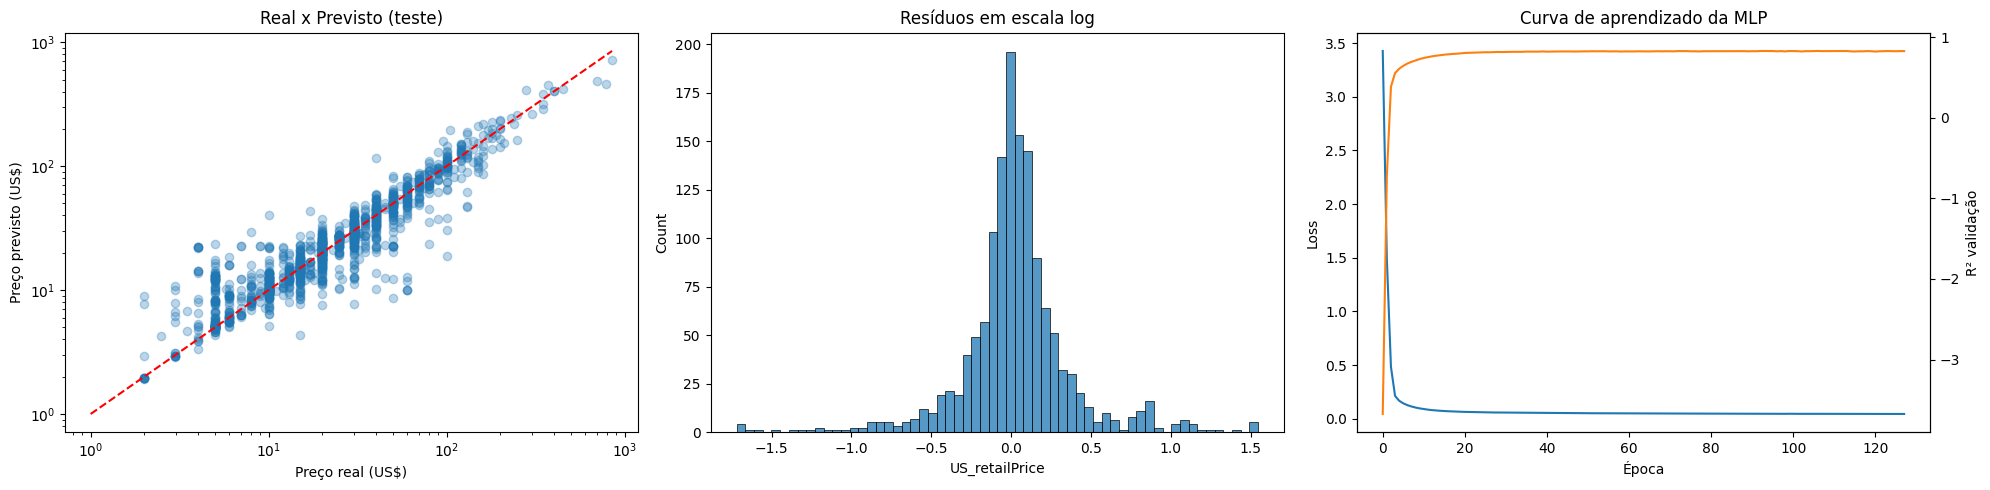

In [23]:
pred_test = best_ann.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].scatter(y_test, pred_test, alpha=0.3)
lim = [1, max(y_test.max(), pred_test.max())]
axes[0].plot(lim, lim, 'r--')
axes[0].set(xscale='log', yscale='log', xlabel='Preço real (US$)', ylabel='Preço previsto (US$)',
            title='Real x Previsto (teste)')

res = np.log1p(pred_test) - np.log1p(y_test)
sns.histplot(res, bins=60, ax=axes[1])
axes[1].set_title('Resíduos em escala log')

mlp_final = best_ann.regressor_.named_steps['reg']
axes[2].plot(mlp_final.loss_curve_, label='Loss treino')
if mlp_final.validation_scores_ is not None:
    ax2 = axes[2].twinx()
    ax2.plot(mlp_final.validation_scores_, color='tab:orange', label='R² validação')
    ax2.set_ylabel('R² validação')
axes[2].set(title='Curva de aprendizado da MLP', xlabel='Época', ylabel='Loss')
plt.tight_layout(); plt.show()

### Importância das variáveis (Permutation Importance)

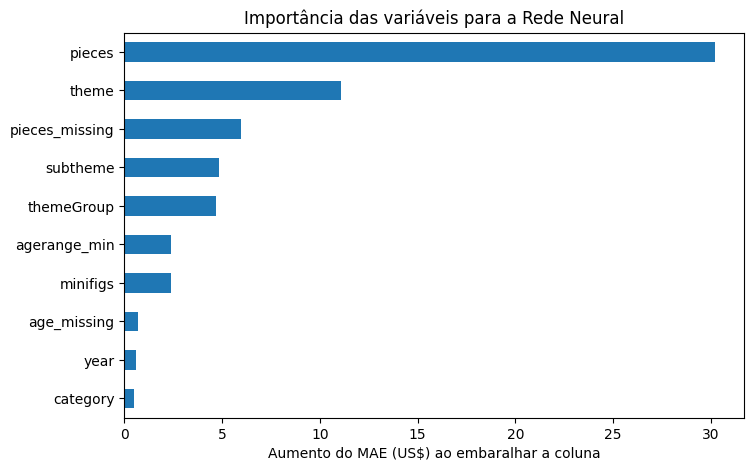

,0
pieces,30.20
theme,11.09
pieces_missing,5.98
subtheme,4.82
themeGroup,4.69
agerange_min,2.39
minifigs,2.37
age_missing,0.70
year,0.59
category,0.51


In [24]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_ann, X_test, y_test, scoring='neg_mean_absolute_error',
                              n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=features).sort_values()

plt.figure(figsize=(8, 5))
imp.plot.barh()
plt.xlabel('Aumento do MAE (US$) ao embaralhar a coluna')
plt.title('Importância das variáveis para a Rede Neural')
plt.show()
imp.sort_values(ascending=False).round(2)

Isso confirma a análise da seção 3: **`pieces`** é de longe a variável mais importante, seguida de tema/categoria, minifigs, ano e idade mínima.

## 6. Criando a coluna `price` para **todos** os sets

In [25]:
# Retreinar o melhor modelo com TODOS os sets que têm preço
final_model = grid.best_estimator_
final_model.fit(X, y)

# Limitar as previsões à faixa de preços observada (evita extrapolações absurdas da rede)
df['price_predicted'] = final_model.predict(df[features]).clip(y.min(), y.max())
df['price'] = df['US_retailPrice'].fillna(df['price_predicted']).round(2)
df['price_source'] = np.where(df['US_retailPrice'].notnull(), 'real', 'previsto (ANN)')

print('Sets sem preço após completar:', df['price'].isnull().sum())
df['price_source'].value_counts()

Sets sem preço após completar: 0


,count
price_source,
previsto (ANN),11475
real,6982


In [26]:
df[df['price_source'] == 'previsto (ANN)'][
    ['set_id', 'name', 'year', 'theme', 'category', 'pieces', 'minifigs', 'price']].sample(10, random_state=1)

,set_id,name,year,theme,category,pieces,minifigs,price
5793,8621-1,Turaga Dume and Nivawk,2004,Bionicle,Normal,179.0,0.0,23.77
14813,ISBN9781513261133-1,Build It! Trains,2018,Books,Book,NaN,0.0,30.22
4849,4524-1,Holiday Calendar,2002,Creator,Normal,231.0,0.0,9.67
5184,3537-1,Skateboard Vert Park Challenge,2003,Sports,Normal,88.0,2.0,19.00
11505,WIJNEGEM-1,Wijnegem 1st Anniversary minifigure pack,2014,Promotional,Other,NaN,0.0,8.99
10422,71002-0,LEGO Minifigures Series 11 {Random bag},2013,Collectable Minifigures,Random,7.0,0.0,19.43
16924,71029-4,Ladybird Girl,2021,Collectable Minifigures,Normal,7.0,1.0,5.32
4702,1545-3,Pen Alpha Team,2002,Gear,Gear,NaN,0.0,9.71
7725,SACRAMENTO-1,Steam Engine,2008,Promotional,Other,78.0,0.0,10.53
2254,5051-1,"Windscreens, Seats and Steering Wheels",1993,Service Packs,Normal,14.0,0.0,10.20


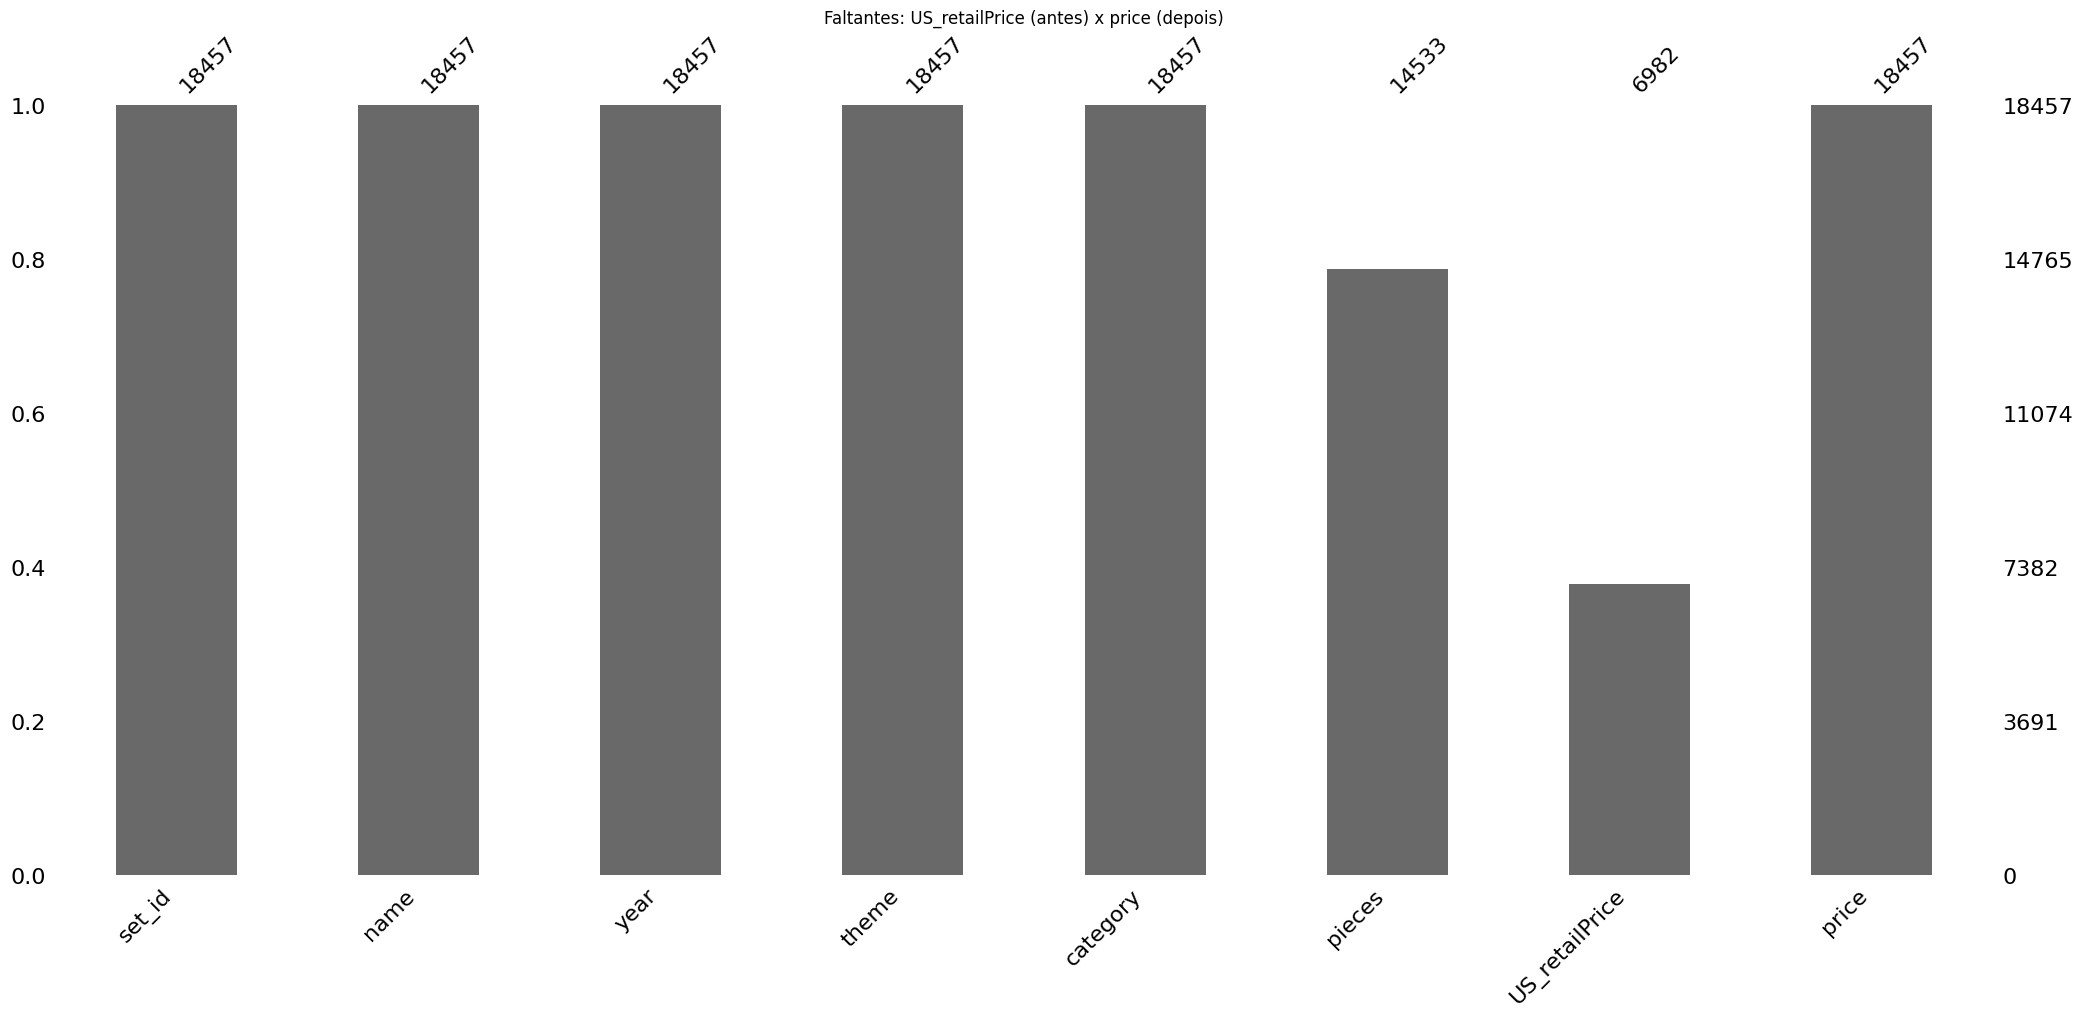

In [27]:
msno.bar(df[['set_id', 'name', 'year', 'theme', 'category', 'pieces', 'US_retailPrice', 'price']])
plt.title('Faltantes: US_retailPrice (antes) x price (depois)')
plt.show()

## 7. Análises e visualizações finais

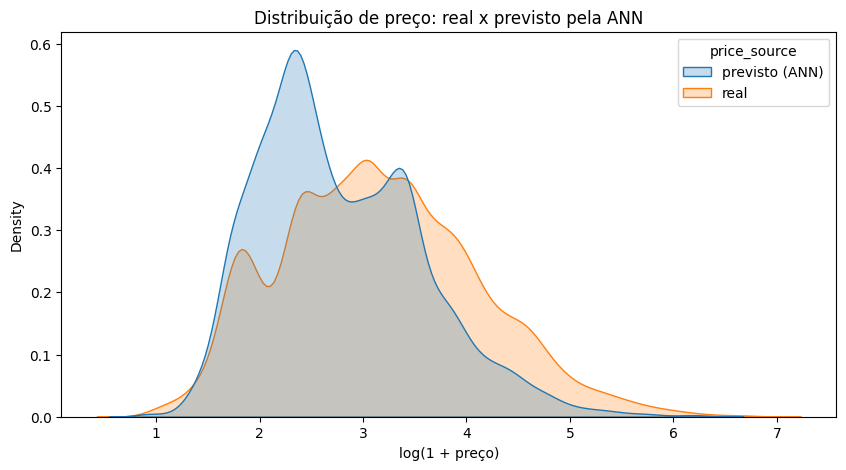

In [28]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x=np.log1p(df['price']), hue='price_source', common_norm=False, fill=True)
plt.xlabel('log(1 + preço)')
plt.title('Distribuição de preço: real x previsto pela ANN')
plt.show()

Os preços previstos tendem a ser **menores** que os reais: sets sem preço nos EUA são, em boa parte, itens pequenos, promocionais ou *gear* (sem `pieces`).

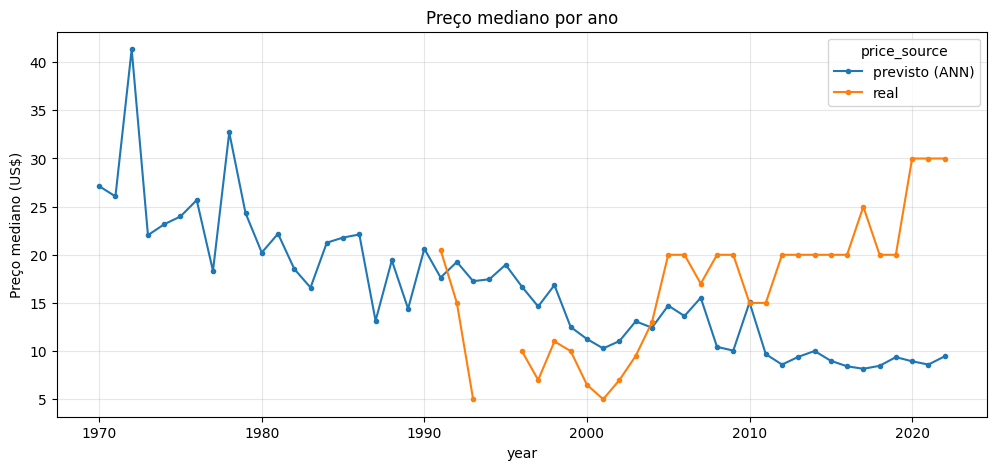

In [29]:
anual = df.groupby(['year', 'price_source'])['price'].median().unstack()
anual.plot(figsize=(12, 5), marker='o', ms=3)
plt.ylabel('Preço mediano (US$)')
plt.title('Preço mediano por ano')
plt.grid(alpha=0.3); plt.show()

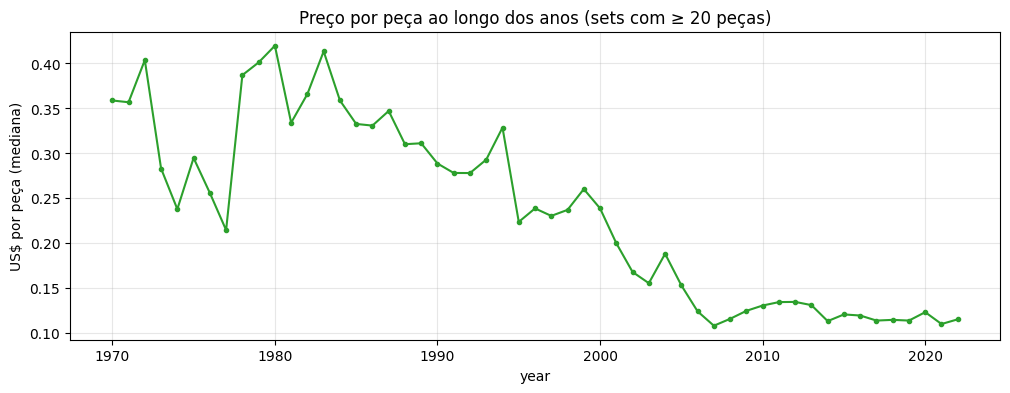

In [30]:
com_pecas = df[df['pieces'] > 0].copy()
com_pecas['preco_por_peca'] = com_pecas['price'] / com_pecas['pieces']
anual_ppp = com_pecas[com_pecas['pieces'] >= 20].groupby('year')['preco_por_peca'].median()
anual_ppp.plot(figsize=(12, 4), color='tab:green', marker='o', ms=3)
plt.ylabel('US$ por peça (mediana)')
plt.title('Preço por peça ao longo dos anos (sets com ≥ 20 peças)')
plt.grid(alpha=0.3); plt.show()

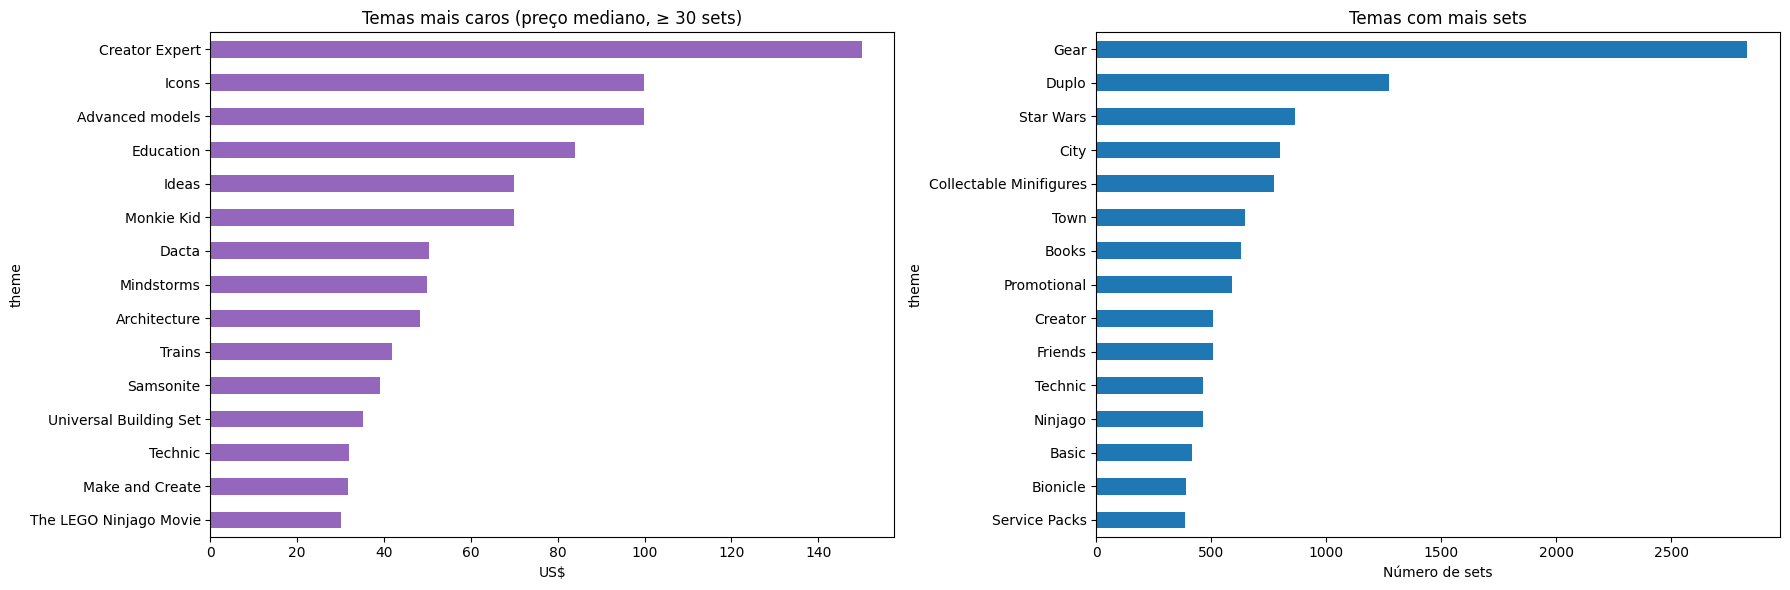

In [31]:
top = df.groupby('theme').agg(sets=('set_id', 'count'), preco_mediano=('price', 'median'),
                             preco_total=('price', 'sum')).query('sets >= 30')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
top.sort_values('preco_mediano').tail(15)['preco_mediano'].plot.barh(ax=axes[0], color='tab:purple')
axes[0].set(title='Temas mais caros (preço mediano, ≥ 30 sets)', xlabel='US$')
top.sort_values('sets').tail(15)['sets'].plot.barh(ax=axes[1], color='tab:blue')
axes[1].set(title='Temas com mais sets', xlabel='Número de sets')
plt.tight_layout(); plt.show()

In [32]:
print('Sets mais caros (real ou previsto):')
df.nlargest(10, 'price')[['set_id', 'name', 'year', 'theme', 'pieces', 'price', 'price_source']]

Sets mais caros (real ou previsto):


,set_id,name,year,theme,pieces,price,price_source
13651,75192-1,Millennium Falcon,2017,Star Wars,7541.0,849.99,real
17046,75313-1,AT-AT,2021,Star Wars,6785.0,849.99,real
10584,2000430-1,Identity and Landscape Kit,2013,Serious Play,2631.0,789.99,real
10585,2000431-1,Connections Kit,2013,Serious Play,2455.0,754.99,real
15267,75252-1,Imperial Star Destroyer,2019,Star Wars,4784.0,699.99,real
16559,10294-1,Titanic,2021,Icons,9090.0,679.99,real
17500,10307-1,Eiffel Tower,2022,Icons,10001.0,629.99,real
17934,75331-1,The Razor Crest,2022,Star Wars,6187.0,599.99,real
15703,10276-1,Colosseum,2020,Icons,9036.0,549.99,real
17962,76210-1,Hulkbuster,2022,Marvel Super Heroes,4049.0,549.99,real


In [33]:
# Salvar resultado
df.to_csv('lego_sets_com_preco.csv', index=False)
print('Arquivo salvo: lego_sets_com_preco.csv', df.shape)

Arquivo salvo: lego_sets_com_preco.csv (18457, 16)


## Conclusões

- Cerca de 60% dos sets não tinham preço nos EUA; após a modelagem **100% dos sets possuem a coluna `price`** (real quando disponível, prevista pela ANN caso contrário — ver `price_source`).
- As variáveis mais importantes para o preço são **número de peças**, **tema/grupo de tema**, **categoria**, **minifigs**, **ano** e **idade mínima**.
- A rede neural (`MLPRegressor`), com pré-processamento adequado (imputação, `log1p`, padronização e one-hot) e alvo em escala log, supera o baseline e a regressão linear.
- **Limitações:** itens sem contagem de peças (gear, livros, colecionáveis) são mais difíceis de prever; o modelo não considera inflação explicitamente nem licenças/raridade além do tema. Melhorias possíveis: usar texto do `name` (ex.: TF-IDF), ajustar preços pela inflação e testar outros modelos (Random Forest, Gradient Boosting) para comparação.